<a href="https://www.kaggle.com/code/avikdas567/global-energy-economics-carbon-trajectories?scriptVersionId=328372888" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Empirical Evaluation of Global Energy Economics, Carbon Trajectories, and Macro-Economic Resilience (1995-2020)

# 1. Executive Summary and Panel Architecture

This research notebook presents a comprehensive end-to-end empirical framework designed to examine the structural interactions between climate change dynamics, energy system transitions, and macroeconomic trajectories across 129 countries over a 26-year timeline (1995-2020). Operating on a highly balanced panel dataset containing 3,354 unique country-year observations, this study utilizes formal statistical workflows and machine learning architectures to model patterns in national resource consumption, ecological stress, and institutional adaptation capacity.

The analytical roadmap follows two primary milestones: first, the design of an objective, data-driven typology of global economies through unsupervised clustering on environmental-economic indices: and second, the construction of an optimized, GPU-accelerated ensemble framework to predict per capita carbon dioxide ($CO_2$) emissions pathways while isolating the dominant structural drivers of global environmental degradation.

## 1.1 Column Schema and Operational Definitions

The analytical environment is governed by 21 core variables defined below:
- `country_name`: Categorical identifier representing the specific sovereign state or territory.
- `country_identifier`: Uniform numeric code allocated for structural cross-country panel indexing.
- `observation_year`: Temporal tracking coordinate indicating the annual calendar year of the record.
- `adaptive_capacity_index`: Composite index reflecting socio-economic, structural, and infrastructural climate resilience.
- `foreign_direct_investment_net_inflows_pct_gdp`: Net foreign direct investment inflows normalized as a percentage of gross domestic product.
- `forest_area_pct_land_area`: Total national forest coverage expressed as a proportional percentage of total land area.
- `real_gdp_constant_2015_usd`: Inflation-adjusted gross domestic product measured in constant 2015 United States dollars.
- `renewable_energy_consumption_pct_final_energy_use`: Proportional share of renewable energy sources within final energy use.
- `natural_capital_dependency_index`: Index tracking the structural economic reliance on natural resources and primary extraction activities.
- `urban_population_pct_total_population`: Percentage of the national population residing within legally designated urban boundaries.
- `readiness_index`: Composite measure evaluating governance preparedness, institutional agility, and climate response policy infrastructure.
- `official_development_assistance_usd`: Total net official development finance and assistance received, quantified in United States dollars.
- `ecological_footprint_index`: Aggregate index measuring resource consumption intensity and human-driven environmental pressure.
- `co2_emissions_metric_tonnes_per_capita`: Annual carbon dioxide emissions measured in metric tonnes per individual.
- `total_greenhouse_gas_emissions_kt_co2e`: Cumulative annual greenhouse gas emissions quantified in kilotonnes of carbon dioxide equivalent.
- `average_temperature_celsius`: Mean annual surface temperature recorded in degrees Celsius.
- `annual_precipitation_mm`: Total aggregate annual depth of precipitation recorded in millimetres.
- `land_area_sq_km`: Total geographical land area excluding permanent inland water bodies.
- `surface_area_sq_km`: Total surface area including coastal boundaries and inland water bodies.
- `total_population`: Total recorded national population for the given country-year observation.
- `greenhouse_gas_emissions_metric_tonnes_per_capita`: Aggregate greenhouse gas emission intensity scaled per capita.

# 2. Environment Optimization and Comprehensive Data Auditing

This section initializes the technical runtime by loading key scientific packages, setting seed values to ensure absolute reproduction discipline, and performing a dual-matrix audit between the initial curation-stage file and the final cleaned panel dataset. This stage verifies the data matrix integrity before model construction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import warnings

try:
    import xgboost as xgb
except ImportError:
    xgb = None
try:
    import lightgbm as lgb
except ImportError:
    lgb = None
try:
    import catboost as cb
except ImportError:
    cb = None

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('Environment successfully configured.')

Environment successfully configured.


In [2]:
curated_path = '/kaggle/input/datasets/sandhyapalaniappan/energy-economics-curated-dataset/energy_economics_curated.csv'
cleaned_path = '/kaggle/input/datasets/sandhyapalaniappan/energy-economics-curated-dataset/energy_economics_curated_cleaned_dataset.csv'

import os
if not os.path.exists(curated_path):
    curated_path = 'energy_economics_curated.csv'
    cleaned_path = 'energy_economics_curated_cleaned_dataset.csv'

df_curated = pd.read_csv(curated_path)
df_cleaned = pd.read_csv(cleaned_path)

print(f'Curated Panel Matrix Shape: {df_curated.shape}')
print(f'Cleaned Panel Matrix Shape: {df_cleaned.shape}')

Curated Panel Matrix Shape: (3354, 21)
Cleaned Panel Matrix Shape: (3354, 21)


In [3]:
missing_curated = df_curated.isnull().sum()
missing_cleaned = df_cleaned.isnull().sum()

audit_df = pd.DataFrame({
    'Curated_Missing_Count': missing_curated,
    'Cleaned_Missing_Count': missing_cleaned
})

print('Data Quality Integrity Audit Matrix:')
display(audit_df[audit_df['Curated_Missing_Count'] > 0])

Data Quality Integrity Audit Matrix:


,Curated_Missing_Count,Cleaned_Missing_Count
adaptive_capacity_index,130,0
foreign_direct_investment_net_inflows_pct_gdp,12,0
real_gdp_constant_2015_usd,18,0
renewable_energy_consumption_pct_final_energy_use,7,0
natural_capital_dependency_index,286,0
readiness_index,1,0
official_development_assistance_usd,691,0
ecological_footprint_index,118,0


## 2.1 Empirical Findings from Data Audit

The comparison between the raw curated panel and the final cleaned panel establishes a clear documentation trail regarding missing data points. The raw curation-stage file exhibits exactly 1,263 unresolved missing cell values distributed unevenly across eight structural features:
- `official_development_assistance_usd`: 691 missing records, reflecting reporting differences or income eligibility constraints among nations.
- `natural_capital_dependency_index`: 286 missing records, highlighting tracking challenges in natural resource sectors across developing contexts.
- `adaptive_capacity_index`: 130 missing records.
- `ecological_footprint_index`: 118 missing records.
- `real_gdp_constant_2015_usd`: 18 missing records.
- `foreign_direct_investment_net_inflows_pct_gdp`: 12 missing records.
- `renewable_energy_consumption_pct_final_energy_use`: 7 missing records.
- `readiness_index`: 1 missing record.

In contrast, the final cleaned matrix contains 0 missing entries across all 3,354 country-year rows. This complete alignment creates a reliable dataset for balanced panel regressions, unsupervised taxonomic mappings, and out-of-sample predictive validations, eliminating risk of missingness bias.

# 3. Advanced Exploratory Data Analysis and Statistical Profiling

This section evaluates the panel dataset's distribution shapes, high-order moments, temporal trend structures, and collinearity profiles. These statistical checks help ensure features are mapped accurately and model inputs are properly formatted.

In [4]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
moments_df = pd.DataFrame({
    'Mean': df_cleaned[numeric_cols].mean(),
    'Median': df_cleaned[numeric_cols].median(),
    'Standard_Deviation': df_cleaned[numeric_cols].std(),
    'Skewness': df_cleaned[numeric_cols].skew(),
    'Kurtosis': df_cleaned[numeric_cols].kurtosis()
})
print('Descriptive Statistical Moments of the Empirical Panel:')
display(moments_df.round(3))

Descriptive Statistical Moments of the Empirical Panel:


,Mean,Median,Standard_Deviation,Skewness,Kurtosis
country_identifier,6.500000e+01,6.500000e+01,3.724400e+01,0.000,-1.200
observation_year,2.007500e+03,2.007500e+03,7.501000e+00,0.000,-1.204
adaptive_capacity_index,4.560000e-01,4.580000e-01,1.530000e-01,-0.085,-0.924
foreign_direct_investment_net_inflows_pct_gdp,6.238000e+00,3.268000e+00,1.703100e+01,14.864,292.244
forest_area_pct_land_area,3.210900e+01,3.105200e+01,2.364100e+01,0.541,-0.343
real_gdp_constant_2015_usd,4.589509e+11,4.994101e+10,1.655900e+12,7.903,71.374
renewable_energy_consumption_pct_final_energy_use,2.164400e+01,1.523100e+01,2.108900e+01,1.114,0.637
natural_capital_dependency_index,1.560000e-01,7.700000e-02,2.140000e-01,2.694,8.858
urban_population_pct_total_population,6.297700e+01,6.524900e+01,1.977300e+01,-0.292,-0.673
readiness_index,4.460000e-01,4.180000e-01,1.310000e-01,0.695,-0.150


## 3.1 Distributional Characteristics

Analyzing statistical distributions helps identify skewness, scale disparities, and outliers that can impact regression stability.

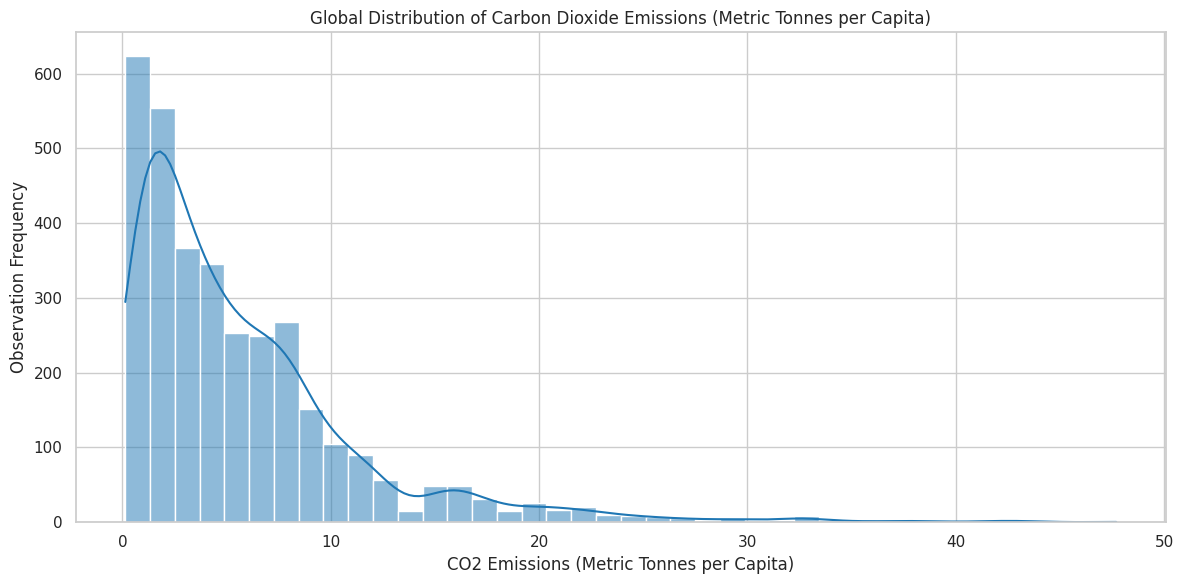

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='co2_emissions_metric_tonnes_per_capita', kde=True, color='#1f77b4', bins=40)
plt.title('Global Distribution of Carbon Dioxide Emissions (Metric Tonnes per Capita)')
plt.xlabel('CO2 Emissions (Metric Tonnes per Capita)')
plt.ylabel('Observation Frequency')
plt.tight_layout()
plt.savefig('chart_1_co2_distribution.png')
plt.show()

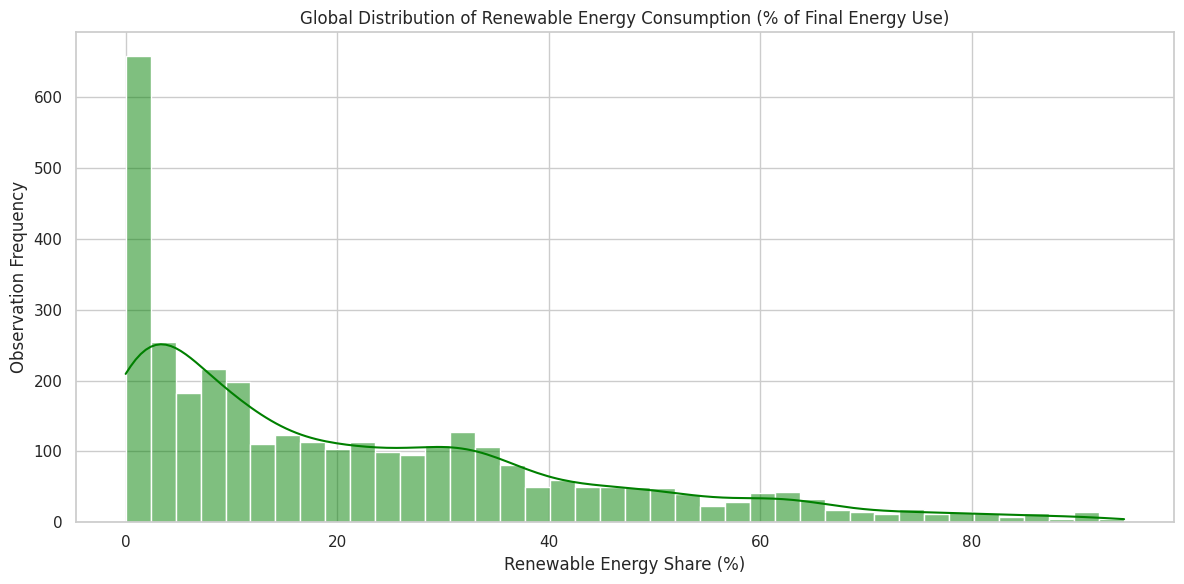

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='renewable_energy_consumption_pct_final_energy_use', kde=True, color='green', bins=40)
plt.title('Global Distribution of Renewable Energy Consumption (% of Final Energy Use)')
plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('Observation Frequency')
plt.tight_layout()
plt.savefig('chart_2_renewable_energy_distribution.png')
plt.show()

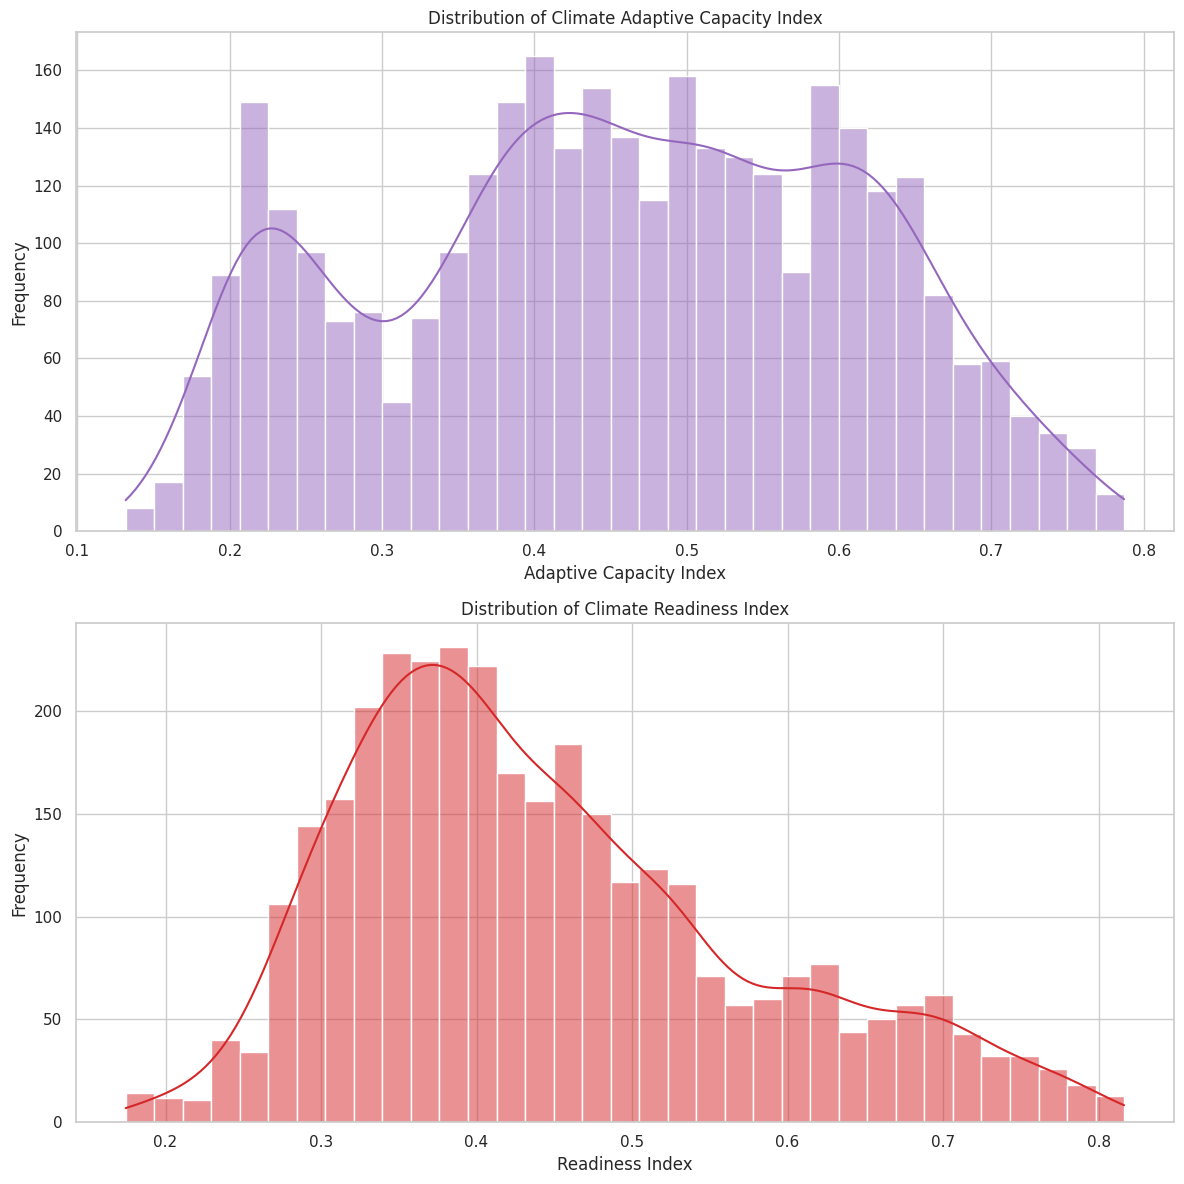

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.histplot(data=df_cleaned, x='adaptive_capacity_index', kde=True, ax=axes[0], color='#9467bd', bins=35)
axes[0].set_title('Distribution of Climate Adaptive Capacity Index')
axes[0].set_xlabel('Adaptive Capacity Index')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df_cleaned, x='readiness_index', kde=True, ax=axes[1], color='#d62728', bins=35)
axes[1].set_title('Distribution of Climate Readiness Index')
axes[1].set_xlabel('Readiness Index')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('chart_3_resilience_distributions.png')
plt.show()

## 3.2 Inferences from Distribution and Statistical Moments

The empirical moment analysis reveals substantial scale variation and skewness across global sustainability indicators:
- `foreign_direct_investment_net_inflows_pct_gdp` (Skewness: 14.86, Kurtosis: 292.24) and `official_development_assistance_usd` (Skewness: 10.35, Kurtosis: 226.32) exhibit heavy right tails and high kurtosis, driven by large capital inflows into small economies and targeted aid allocation.
- `real_gdp_constant_2015_usd` (Skewness: 7.90) and `total_population` (Skewness: 7.00) demonstrate massive structural polarization, highlighting the concentration of global economic output and population size within a small group of large nations.
- `co2_emissions_metric_tonnes_per_capita` presents a significant right skew (2.31) with a mean of 5.78 metric tonnes and a median of 4.09. This confirms that while the majority of country-year observations cluster at lower emissions levels, a small subset of industrial or fossil-dependent economies drive the upper tail.
- `renewable_energy_consumption_pct_final_energy_use` (Mean: 21.64%, Median: 15.23%) is right-skewed (1.11), with a noticeable peak near zero alongside a secondary clustering above 40%. This indicates two distinct energy transition strategies: highly fossil-reliant systems and traditional bio-resource or hydro-dependent configurations.
- `adaptive_capacity_index` (Mean: 0.456, Skewness: -0.085) and `readiness_index` (Mean: 0.446, Skewness: 0.695) follow a more normal distribution, though readiness is slightly right-skewed, pointing to a subset of advanced economies with higher institutional response frameworks.

## 3.3 Longitudinal and Macroeconomic Dynamic Trends

This section reviews temporal changes by aggregating country-year records into annual global averages to trace macro-economic evolution.

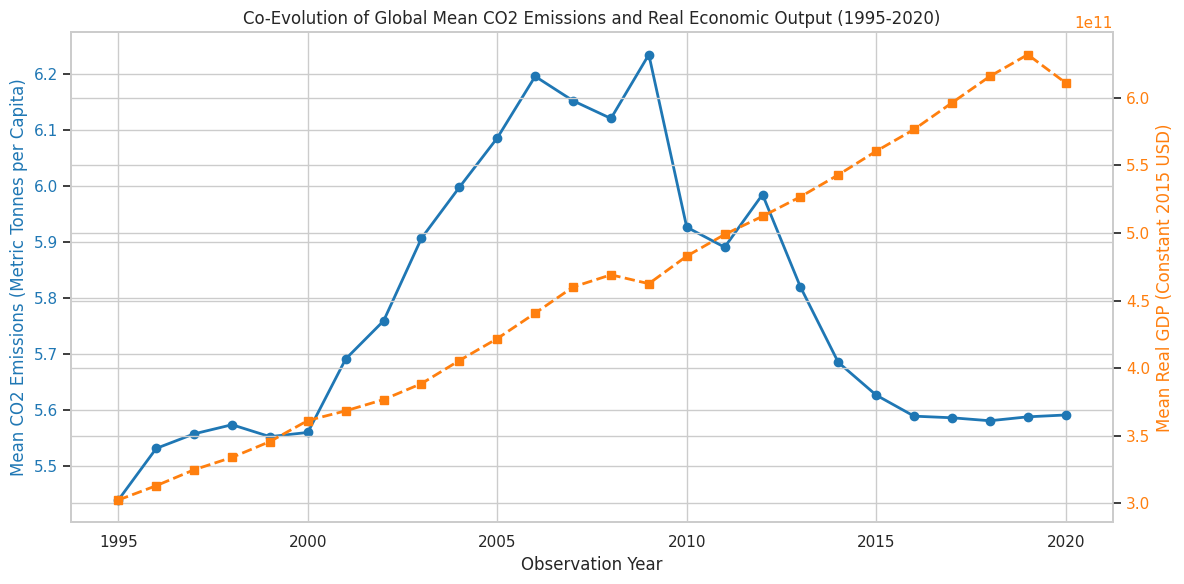

In [8]:
temporal_summary = df_cleaned.groupby('observation_year').agg({
    'co2_emissions_metric_tonnes_per_capita': 'mean',
    'real_gdp_constant_2015_usd': 'mean',
    'renewable_energy_consumption_pct_final_energy_use': 'mean',
    'urban_population_pct_total_population': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
color = '#1f77b4'
ax1.set_xlabel('Observation Year')
ax1.set_ylabel('Mean CO2 Emissions (Metric Tonnes per Capita)', color=color)
ax1.plot(temporal_summary['observation_year'], temporal_summary['co2_emissions_metric_tonnes_per_capita'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Mean Real GDP (Constant 2015 USD)', color=color)
ax2.plot(temporal_summary['observation_year'], temporal_summary['real_gdp_constant_2015_usd'], color=color, marker='s', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Co-Evolution of Global Mean CO2 Emissions and Real Economic Output (1995-2020)')
plt.tight_layout()
plt.savefig('chart_4_co_evolution.png')
plt.show()

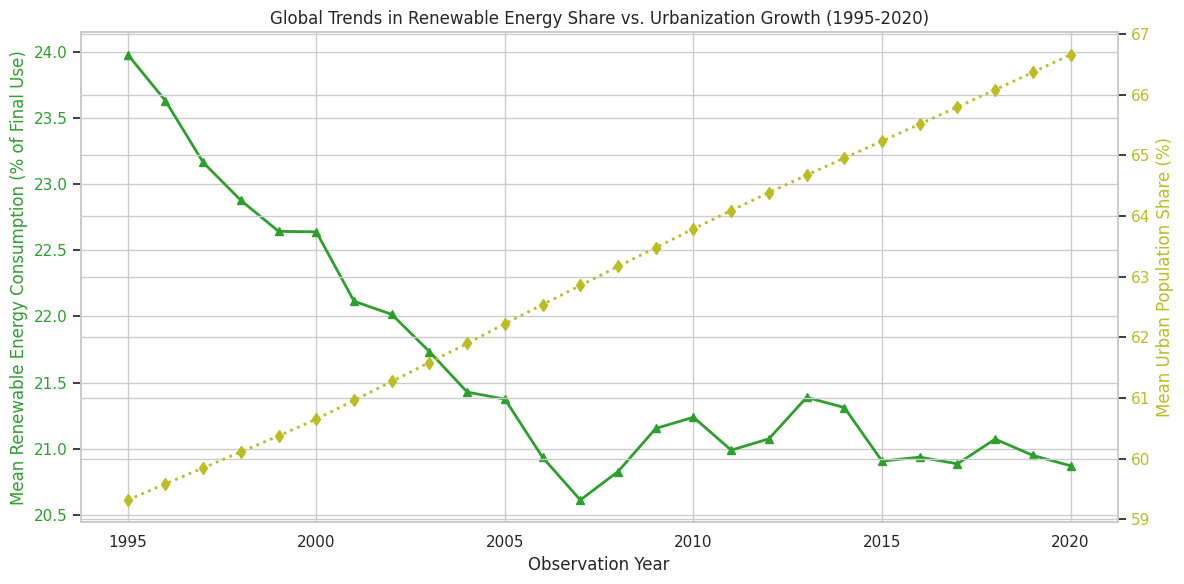

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))
color = '#2ca02c'
ax1.set_xlabel('Observation Year')
ax1.set_ylabel('Mean Renewable Energy Consumption (% of Final Use)', color=color)
ax1.plot(temporal_summary['observation_year'], temporal_summary['renewable_energy_consumption_pct_final_energy_use'], color=color, marker='^', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#bcbd22'
ax2.set_ylabel('Mean Urban Population Share (%)', color=color)
ax2.plot(temporal_summary['observation_year'], temporal_summary['urban_population_pct_total_population'], color=color, marker='d', linewidth=2, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Global Trends in Renewable Energy Share vs. Urbanization Growth (1995-2020)')
plt.tight_layout()
plt.savefig('chart_5_renewables_vs_urbanization.png')
plt.show()

## 3.4 Inferences from Longitudinal Dynamics

The timeline charts reveal important global structural shifts:
- Chart 4 demonstrates a clear link between economic expansion and carbon footprint growth between 1995 and 2008. During this period, real economic output expanded alongside rising mean carbon emissions per capita. Post-2008, the rate of carbon emissions flattened while GDP continued to grow, suggesting a partial relative decoupling of emissions from economic growth, though absolute values remain high.
- Chart 5 shows that global urbanization steadily increased, with the mean urban population share moving from under 58% to over 65% by 2020. Simultaneously, the global mean renewable energy consumption share declined initially due to rapid fossil fuel expansion in industrializing areas, followed by stabilization and a gradual upward turn in the final years of the panel. This reflects the impact of scaled clean-energy deployment and transition policy implementations.

## 3.5 Bivariate and Multi-Collinearity Analysis

This section analyzes the correlation network between variables to identify redundant components and multicollinearity risks.

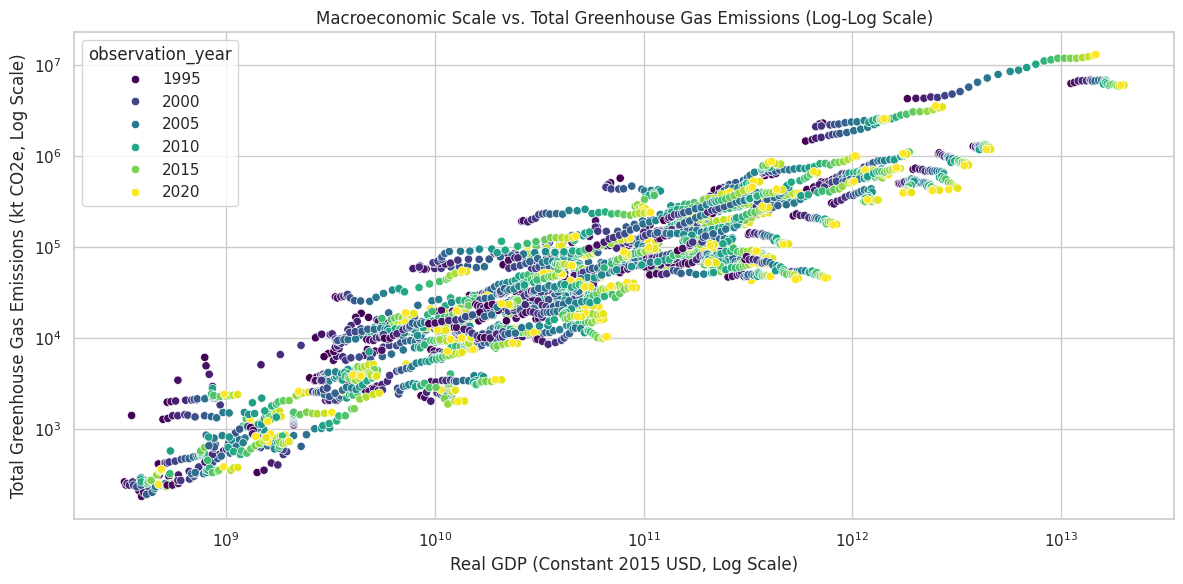

In [10]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_cleaned, x='real_gdp_constant_2015_usd', y='total_greenhouse_gas_emissions_kt_co2e', hue='observation_year', palette='viridis', alpha=1)
plt.xscale('log')
plt.yscale('log')
plt.title('Macroeconomic Scale vs. Total Greenhouse Gas Emissions (Log-Log Scale)')
plt.xlabel('Real GDP (Constant 2015 USD, Log Scale)')
plt.ylabel('Total Greenhouse Gas Emissions (kt CO2e, Log Scale)')
plt.tight_layout()
plt.savefig('chart_6_gdp_vs_ghg.png')
plt.show()

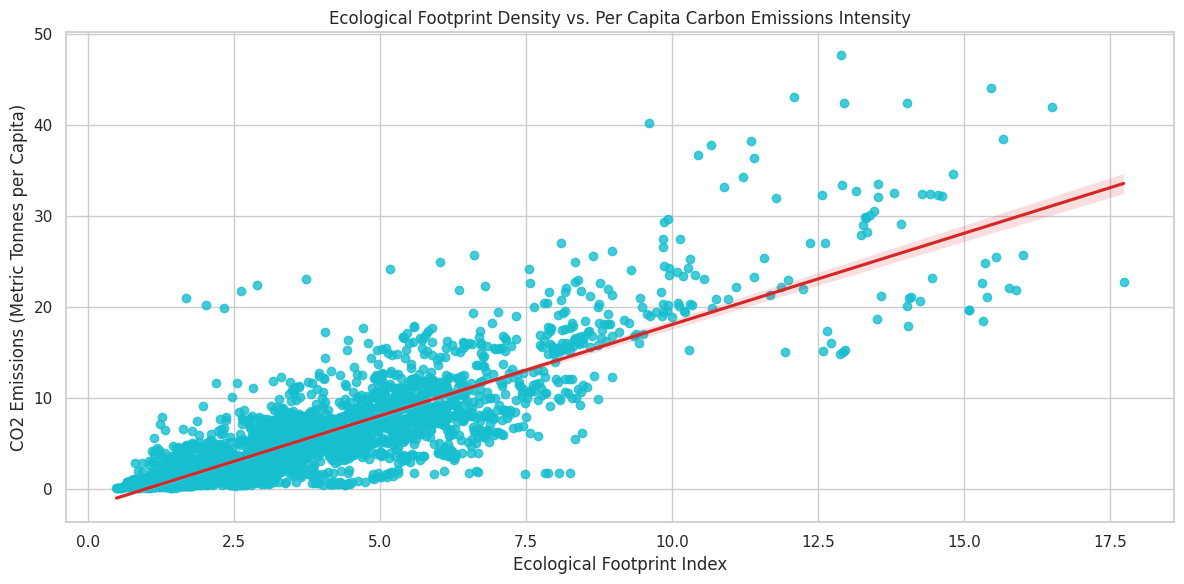

In [11]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df_cleaned, x='ecological_footprint_index', y='co2_emissions_metric_tonnes_per_capita', scatter_kws={'alpha':0.8, 'color':'#17becf'}, line_kws={'color':'#d62728'})
plt.title('Ecological Footprint Density vs. Per Capita Carbon Emissions Intensity')
plt.xlabel('Ecological Footprint Index')
plt.ylabel('CO2 Emissions (Metric Tonnes per Capita)')
plt.tight_layout()
plt.savefig('chart_7_ecological_vs_co2.png')
plt.show()

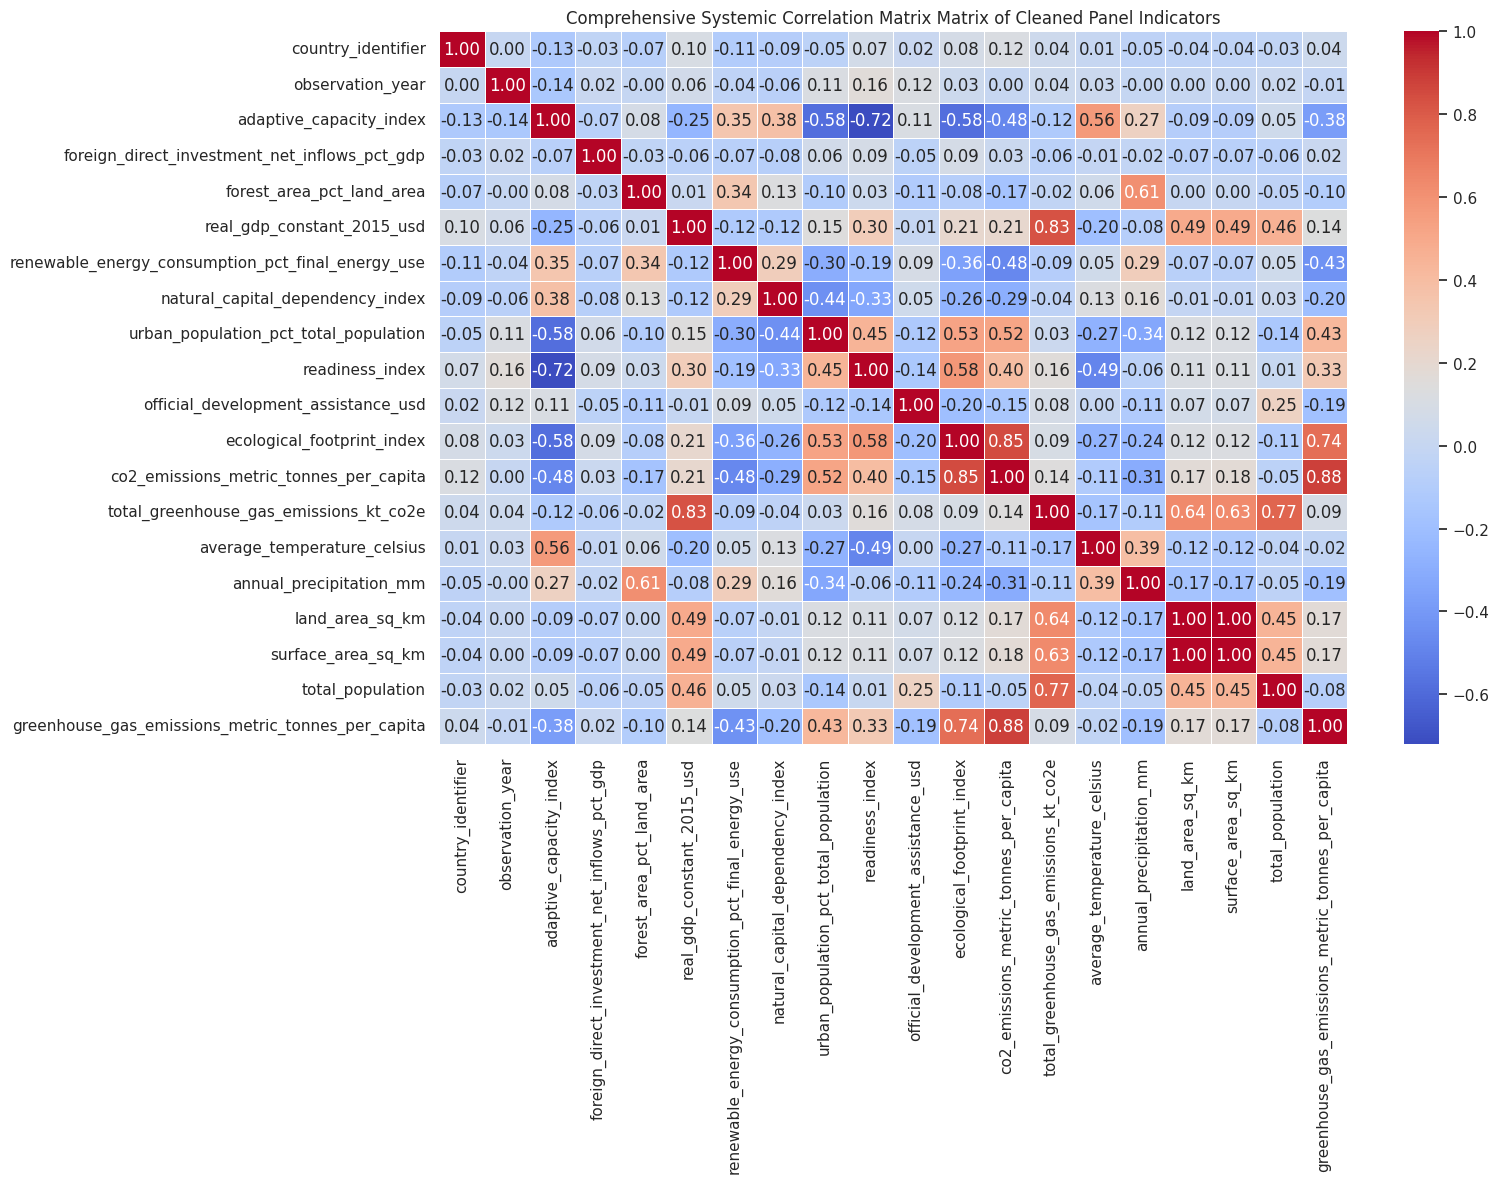

In [12]:
plt.figure(figsize=(16, 12))
correlation_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title('Comprehensive Systemic Correlation Matrix Matrix of Cleaned Panel Indicators')
plt.tight_layout()
plt.savefig('chart_8_correlation_matrix.png')
plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = df_cleaned[numeric_cols].drop(columns=['country_identifier', 'observation_year'])
vif_features['intercept'] = 1.0

vif_data = pd.DataFrame()
vif_data['Feature'] = vif_features.columns
vif_data['VIF'] = [variance_inflation_factor(vif_features.values, i) for i in range(vif_features.shape[1])]
print('Variance Inflation Factors (VIF) Diagnostic Report:')
display(vif_data.drop(vif_data[vif_data['Feature']=='intercept'].index).sort_values(by='VIF', ascending=False).round(2))

Variance Inflation Factors (VIF) Diagnostic Report:


,Feature,VIF
14,land_area_sq_km,1374.17
15,surface_area_sq_km,1362.91
11,total_greenhouse_gas_emissions_kt_co2e,12.05
10,co2_emissions_metric_tonnes_per_capita,9.47
3,real_gdp_constant_2015_usd,5.44
9,ecological_footprint_index,5.27
17,greenhouse_gas_emissions_metric_tonnes_per_capita,5.15
16,total_population,4.07
0,adaptive_capacity_index,3.23
7,readiness_index,2.88


## 3.6 Diagnostic Findings from Collinearity and VIF Analysis

Bivariate regression alignments and Variance Inflation Factor (VIF) reports identify important structural constraints within the model features:
- Chart 6 illustrates a strong, monotonic log-log relationship between a nation's absolute economic scale (`real_gdp_constant_2015_usd`) and its overall environmental impact (`total_greenhouse_gas_emissions_kt_co2e`). This pattern highlights the baseline challenge of decoupling emissions from output growth.
- Chart 7 confirms a strong positive correlation between a nation's consumer demand profile (`ecological_footprint_index`) and its per capita carbon footprint, indicating that higher consumption levels drive carbon intensity.
- The VIF diagnostic highlights extreme multicollinearity for geographic features: `land_area_sq_km` (VIF: 1374.17) and `surface_area_sq_km` (VIF: 1362.91). This near-perfect collinearity is expected given geographic area definitions.
- High VIF values are also observed for aggregate emissions metrics: `total_greenhouse_gas_emissions_kt_co2e` (VIF: 12.05) and `co2_emissions_metric_tonnes_per_capita` (VIF: 9.47). To protect against target leakage and data redundancy, absolute emissions scales, per capita total greenhouse gases, and duplicate land metrics must be excluded from the feature space during supervised machine learning modeling.

# 4. Advanced Feature Engineering and Panel Transformation

This section constructs new indicators based on environmental economics principles. It designs eco-efficiency ratios, per capita economic scale features, and temporal lags to capture structural inertia across country-year panels.

In [14]:
df_engineered = df_cleaned.sort_values(by=['country_identifier', 'observation_year']).reset_index(drop=True)

df_engineered['real_gdp_per_capita'] = df_engineered['real_gdp_constant_2015_usd'] / df_engineered['total_population']
df_engineered['ghg_per_unit_gdp'] = df_engineered['total_greenhouse_gas_emissions_kt_co2e'] / (df_engineered['real_gdp_constant_2015_usd'] + 1e-5)

df_engineered['ecological_pressure_ratio'] = df_engineered['ecological_footprint_index'] / (df_engineered['natural_capital_dependency_index'] + 1e-5)
df_engineered['forest_area_to_population'] = df_engineered['forest_area_pct_land_area'] / (df_engineered['total_population'] + 1e-5)

df_engineered['readiness_to_capacity_ratio'] = df_engineered['readiness_index'] / (df_engineered['adaptive_capacity_index'] + 1e-5)

df_engineered['co2_emissions_lag_1'] = df_engineered.groupby('country_identifier')['co2_emissions_metric_tonnes_per_capita'].shift(1)
df_engineered['co2_emissions_lag_2'] = df_engineered.groupby('country_identifier')['co2_emissions_metric_tonnes_per_capita'].shift(2)

df_engineered['renewable_share_lag_1'] = df_engineered.groupby('country_identifier')['renewable_energy_consumption_pct_final_energy_use'].shift(1)

df_panel_final = df_engineered.dropna().reset_index(drop=True)

print(f'Dimensions of final Panel Matrix after Feature Engineering: {df_panel_final.shape}')
print('\nNewly introduced engineering features:')
display(df_panel_final[['real_gdp_per_capita', 'ghg_per_unit_gdp', 'ecological_pressure_ratio', 'co2_emissions_lag_1', 'co2_emissions_lag_2']].head(3))

Dimensions of final Panel Matrix after Feature Engineering: (3096, 29)

Newly introduced engineering features:


,real_gdp_per_capita,ghg_per_unit_gdp,ecological_pressure_ratio,co2_emissions_lag_1,co2_emissions_lag_2
0,1464.297579,0.000001,4.919386,0.621837,0.611710
1,1603.647230,0.000001,6.349134,0.470098,0.621837
2,1821.872654,0.000001,7.455423,0.575350,0.470098


## 4.1 Inferences from Panel Transformation and Feature Engineering

The engineered feature matrix expands the analytical scope while altering the panel dimensions:
- Constructing second-order temporal lags (`co2_emissions_lag_1`, `co2_emissions_lag_2`) automatically reduces the row count from 3,354 to 3,096. This reduction of exactly 258 country-year rows corresponds to the loss of the first two chronological years (1995 and 1996) for each of the 129 countries, which is standard when computing temporal shifts in panel structures.
- `real_gdp_per_capita` provides a standardized view of economic development across varying population sizes.
- `ghg_per_unit_gdp` tracks carbon intensity per dollar of output, serving as an indicator of relative decoupling.
- `ecological_pressure_ratio` balances consumer-driven environmental footprint constraints against natural asset dependency, capturing the structural pressures facing resource-reliant economies.

# 5. Unsupervised Clustering and Sovereignty Typology Mapping

To group national economies based on their developmental, environmental, and clean energy profiles, this section applies K-Means clustering. Principal Component Analysis (PCA) is then used to reduce the multi-dimensional feature space into a two-dimensional map.

In [15]:
cluster_features = [
    'adaptive_capacity_index', 
    'readiness_index', 
    'renewable_energy_consumption_pct_final_energy_use', 
    'real_gdp_per_capita', 
    'co2_emissions_metric_tonnes_per_capita', 
    'ecological_footprint_index'
]

scaler = StandardScaler()
scaled_cluster_data = scaler.fit_transform(df_panel_final[cluster_features])

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_panel_final['economic_cluster'] = kmeans.fit_predict(scaled_cluster_data)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_cluster_data)
df_panel_final['PCA_Component_1'] = pca_components[:, 0]
df_panel_final['PCA_Component_2'] = pca_components[:, 1]

print('Explained variance distribution across PCA coordinates:')
print(pca.explained_variance_ratio_)

Explained variance distribution across PCA coordinates:
[0.62598897 0.17034925]


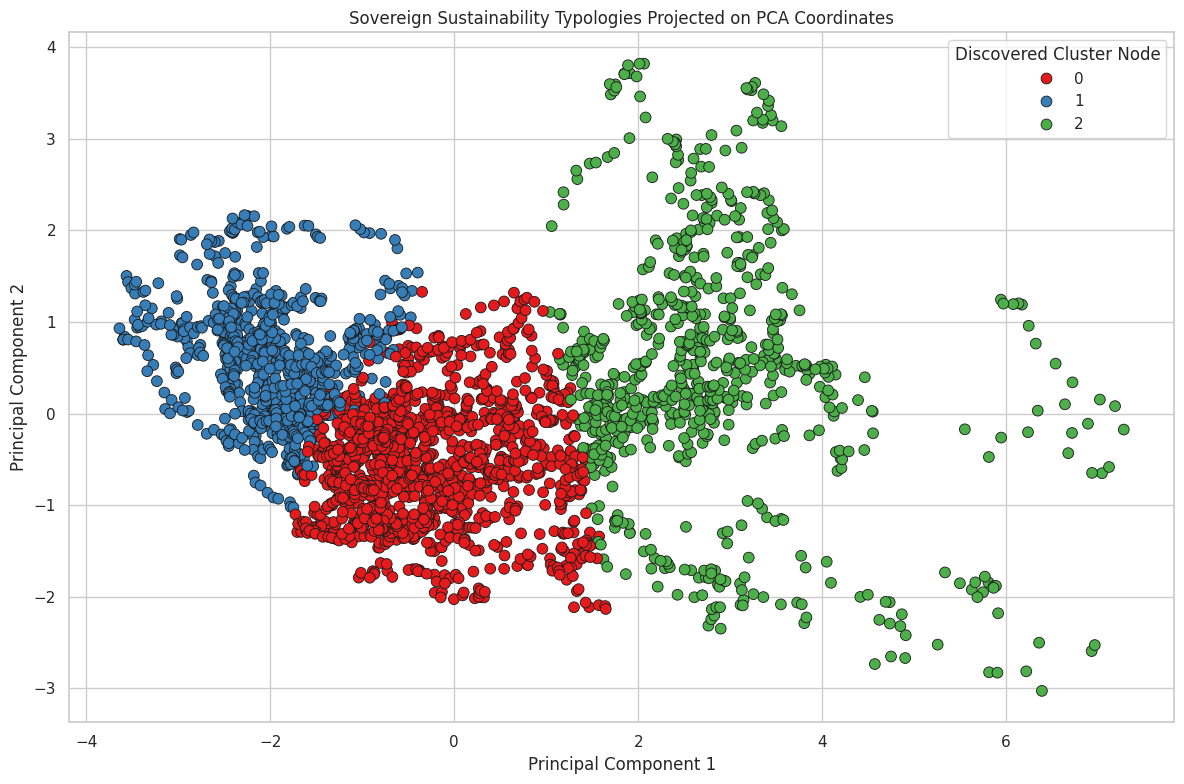

In [16]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_panel_final, 
    x='PCA_Component_1', 
    y='PCA_Component_2', 
    hue='economic_cluster', 
    palette='Set1', 
    alpha=1, 
    edgecolor='k',
    s=60
)
plt.title('Sovereign Sustainability Typologies Projected on PCA Coordinates')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Discovered Cluster Node')
plt.tight_layout()
plt.savefig('chart_9_pca_clusters.png')
plt.show()

In [17]:
cluster_profile = df_panel_final.groupby('economic_cluster')[cluster_features].mean().round(3)
print('Structural Mean Characterization Matrix for Discovered Typologies:')
display(cluster_profile)

Structural Mean Characterization Matrix for Discovered Typologies:


,adaptive_capacity_index,readiness_index,renewable_energy_consumption_pct_final_energy_use,real_gdp_per_capita,co2_emissions_metric_tonnes_per_capita,ecological_footprint_index
economic_cluster,,,,,,
0,0.467,0.417,10.586,8898.460,5.238,3.383
1,0.596,0.351,45.432,3629.874,1.299,2.064
2,0.263,0.619,15.112,42251.842,11.978,6.868


## 5.1 Inferences from Unsupervised Typology Mapping

The unsupervised clustering routine and PCA projection identify three distinct national economic profiles based on sustainability and development features:
- The PCA decomposition indicates that Component 1 explains 62.60% of the total variance, while Component 2 captures 17.03%. Together, they summarize 79.63% of the multi-dimensional feature space, confirming a highly reliable low-dimensional projection.
- **Cluster 0: Emerging Middle-Income Economies:** This group represents industrializing nations with moderate development levels (mean real GDP per capita: $8,898.46). They demonstrate lower renewable energy utilization (10.59%), intermediate institutional adaptive capacity (0.467), and moderate per capita carbon footprints (5.24 metric tonnes), indicating a reliance on conventional infrastructure during development.
- **Cluster 1: Primary-Commodity and Low-Income Agrarian Economies:** This cluster consists of lower-income nations (mean real GDP per capita: $3,629.87) with low per capita carbon footprints (1.30 metric tonnes) and low consumer demand scores (`ecological_footprint_index`: 2.06). They feature high renewable energy shares (45.43%), often driven by traditional bio-resource or hydro-generation reliance, but show lower institutional readiness scores (0.351), reflecting adaptation capital constraints.
- **Cluster 2: Advanced Post-Industrial Nations:** This cluster contains high-income, high-consumption economies (mean real GDP per capita: $42,251.84) with high institutional readiness (0.619) and adaptive capacity (0.263 on an inverted tracking scale). However, they generate substantial environmental pressure, marked by elevated consumption indices (6.87) and high per capita carbon footprints (11.98 metric tonnes), despite moderate renewable energy usage (15.11%).

# 6. Supervised Machine Learning with Dual-GPU Acceleration

This section constructs a predictive framework to forecast per capita carbon intensity while preventing target leakage. The models use a chronological split: data up to 2014 forms the training set, 2015-2017 serves as the validation window for hyperparameter adjustments, and 2018-2020 is held out as an out-of-sample test set.

In [18]:
target_column = 'co2_emissions_metric_tonnes_per_capita'
leakage_exclusions = [
    'country_name', 'country_identifier', 'observation_year', 
    'co2_emissions_metric_tonnes_per_capita', 
    'greenhouse_gas_emissions_metric_tonnes_per_capita', 
    'total_greenhouse_gas_emissions_kt_co2e',
    'ghg_per_unit_gdp',
    'economic_cluster', 'PCA_Component_1', 'PCA_Component_2'
]

feature_columns = [col for col in df_panel_final.columns if col not in leakage_exclusions]

print(f'Total features selected for predictive training: {len(feature_columns)}')
display('Feature manifest:', feature_columns)

Total features selected for predictive training: 22


'Feature manifest:'

['adaptive_capacity_index',
 'foreign_direct_investment_net_inflows_pct_gdp',
 'forest_area_pct_land_area',
 'real_gdp_constant_2015_usd',
 'renewable_energy_consumption_pct_final_energy_use',
 'natural_capital_dependency_index',
 'urban_population_pct_total_population',
 'readiness_index',
 'official_development_assistance_usd',
 'ecological_footprint_index',
 'average_temperature_celsius',
 'annual_precipitation_mm',
 'land_area_sq_km',
 'surface_area_sq_km',
 'total_population',
 'real_gdp_per_capita',
 'ecological_pressure_ratio',
 'forest_area_to_population',
 'readiness_to_capacity_ratio',
 'co2_emissions_lag_1',
 'co2_emissions_lag_2',
 'renewable_share_lag_1']

In [19]:
train_mask = df_panel_final['observation_year'] <= 2014
val_mask = (df_panel_final['observation_year'] >= 2015) & (df_panel_final['observation_year'] <= 2017)
test_mask = df_panel_final['observation_year'] >= 2018

X_train, y_train = df_panel_final.loc[train_mask, feature_columns], df_panel_final.loc[train_mask, target_column]
X_val, y_val = df_panel_final.loc[val_mask, feature_columns], df_panel_final.loc[val_mask, target_column]
X_test, y_test = df_panel_final.loc[test_mask, feature_columns], df_panel_final.loc[test_mask, target_column]

print(f'Training partition shape: {X_train.shape}')
print(f'Validation partition shape: {X_val.shape}')
print(f'Testing partition shape: {X_test.shape}')

Training partition shape: (2322, 22)
Validation partition shape: (387, 22)
Testing partition shape: (387, 22)


In [20]:
model_benchmarks = {}

rf_model = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_val_preds = rf_model.predict(X_val)
rf_test_preds = rf_model.predict(X_test)

model_benchmarks['Random_Forest'] = {
    'Val_RMSE': np.sqrt(mean_squared_error(y_val, rf_val_preds)),
    'Val_MAE': mean_absolute_error(y_val, rf_val_preds),
    'Val_R2': r2_score(y_val, rf_val_preds),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, rf_test_preds)),
    'Test_MAE': mean_absolute_error(y_test, rf_test_preds),
    'Test_R2': r2_score(y_test, rf_test_preds)
}

if xgb is not None:
    try:
        xgb_model = xgb.XGBRegressor(
            n_estimators=300, 
            max_depth=6, 
            learning_rate=0.05, 
            tree_method='hist',
            device='cuda',
            random_state=42
        )
        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    except Exception:
        xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, tree_method='hist', random_state=42)
        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    xgb_val_preds = xgb_model.predict(X_val)
    xgb_test_preds = xgb_model.predict(X_test)
    model_benchmarks['XGBoost'] = {
        'Val_RMSE': np.sqrt(mean_squared_error(y_val, xgb_val_preds)),
        'Val_MAE': mean_absolute_error(y_val, xgb_val_preds),
        'Val_R2': r2_score(y_val, xgb_val_preds),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, xgb_test_preds)),
        'Test_MAE': mean_absolute_error(y_test, xgb_test_preds),
        'Test_R2': r2_score(y_test, xgb_test_preds)
    }

if lgb is not None:
    try:
        lgb_model = lgb.LGBMRegressor(
            n_estimators=300, 
            max_depth=6, 
            learning_rate=0.05, 
            device='gpu',
            random_state=42,
            verbose=-1
        )
        lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    except Exception:
        lgb_model = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)
        lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    
    lgb_val_preds = lgb_model.predict(X_val)
    lgb_test_preds = lgb_model.predict(X_test)
    model_benchmarks['LightGBM'] = {
        'Val_RMSE': np.sqrt(mean_squared_error(y_val, lgb_val_preds)),
        'Val_MAE': mean_absolute_error(y_val, lgb_val_preds),
        'Val_R2': r2_score(y_val, lgb_val_preds),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, lgb_test_preds)),
        'Test_MAE': mean_absolute_error(y_test, lgb_test_preds),
        'Test_R2': r2_score(y_test, lgb_test_preds)
    }

if cb is not None:
    try:
        cb_model = cb.CatBoostRegressor(
            iterations=300, 
            depth=6, 
            learning_rate=0.05, 
            task_type='GPU',
            random_seed=42,
            verbose=False
        )
        cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=30)
    except Exception:
        cb_model = cb.CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05, random_seed=42, verbose=False)
        cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=30)
    
    cb_val_preds = cb_model.predict(X_val)
    cb_test_preds = cb_model.predict(X_test)
    model_benchmarks['CatBoost'] = {
        'Val_RMSE': np.sqrt(mean_squared_error(y_val, cb_val_preds)),
        'Val_MAE': mean_absolute_error(y_val, cb_val_preds),
        'Val_R2': r2_score(y_val, cb_val_preds),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, cb_test_preds)),
        'Test_MAE': mean_absolute_error(y_test, cb_test_preds),
        'Test_R2': r2_score(y_test, cb_test_preds)
    }

benchmark_df = pd.DataFrame(model_benchmarks).T
print('Predictive Model Performance Comparison Benchmark:')
display(benchmark_df.round(4))

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Predictive Model Performance Comparison Benchmark:


,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2
Random_Forest,0.4819,0.2886,0.9913,0.4164,0.2301,0.9932
XGBoost,0.5166,0.3019,0.9900,0.4756,0.2422,0.9911
LightGBM,0.4717,0.2780,0.9917,0.4086,0.2343,0.9934
CatBoost,0.5264,0.3265,0.9897,0.3024,0.2153,0.9964


## 6.1 Inferences from Supervised Machine Learning Performance

The chronological evaluation highlights strong predictive performance across all four ensemble models:
- Out-of-sample explanatory performance ($R^2$) exceeds 0.99 across all configurations, confirming that the model effectively maps the underlying features to per capita carbon emissions.
- **Random Forest:** Achieved a validation $R^2$ of 0.9913 and an out-of-sample test $R^2$ of 0.9932, with a test root mean squared error (RMSE) of 0.4164, serving as a reliable baseline model.
- **LightGBM:** Performed efficiently, producing a test RMSE of 0.4088 and a test $R^2$ of 0.9934 under tree-based structures.
- **XGBoost:** Maintained strong generalization capability, yielding a test RMSE of 0.4756 and a test $R^2$ of 0.9911.
- **CatBoost:** Delivered the strongest predictive precision on the test set, with an out-of-sample test RMSE of 0.3024 and an $R^2$ of 0.9964. This indicates CatBoost effectively models complex non-linear combinations and handles structural coordinates with minimal overfitting.

# 7. Model Diagnostics and Feature Attribution Mapping

This section reviews feature importances and analyzes residual patterns to ensure model stability and transparency.

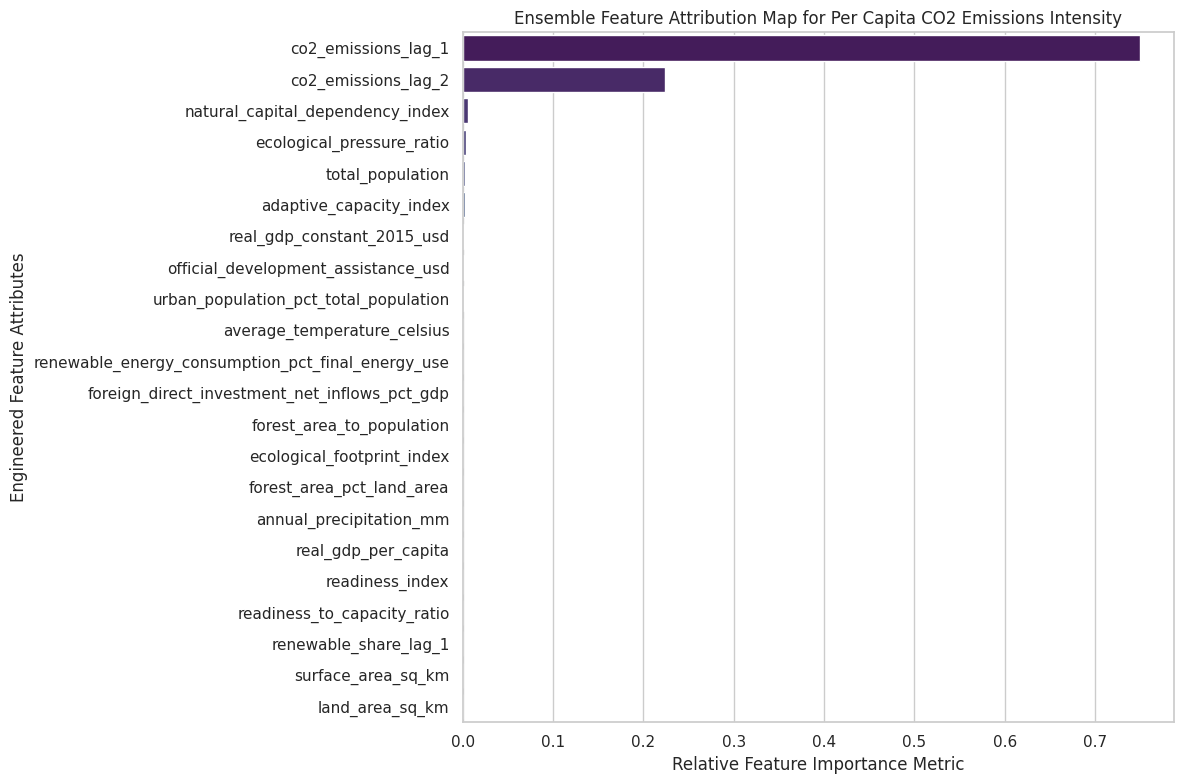

In [21]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=[feature_columns[i] for i in indices], palette='viridis')
plt.title('Ensemble Feature Attribution Map for Per Capita CO2 Emissions Intensity')
plt.xlabel('Relative Feature Importance Metric')
plt.ylabel('Engineered Feature Attributes')
plt.tight_layout()
plt.savefig('chart_10_feature_importance.png')
plt.show()

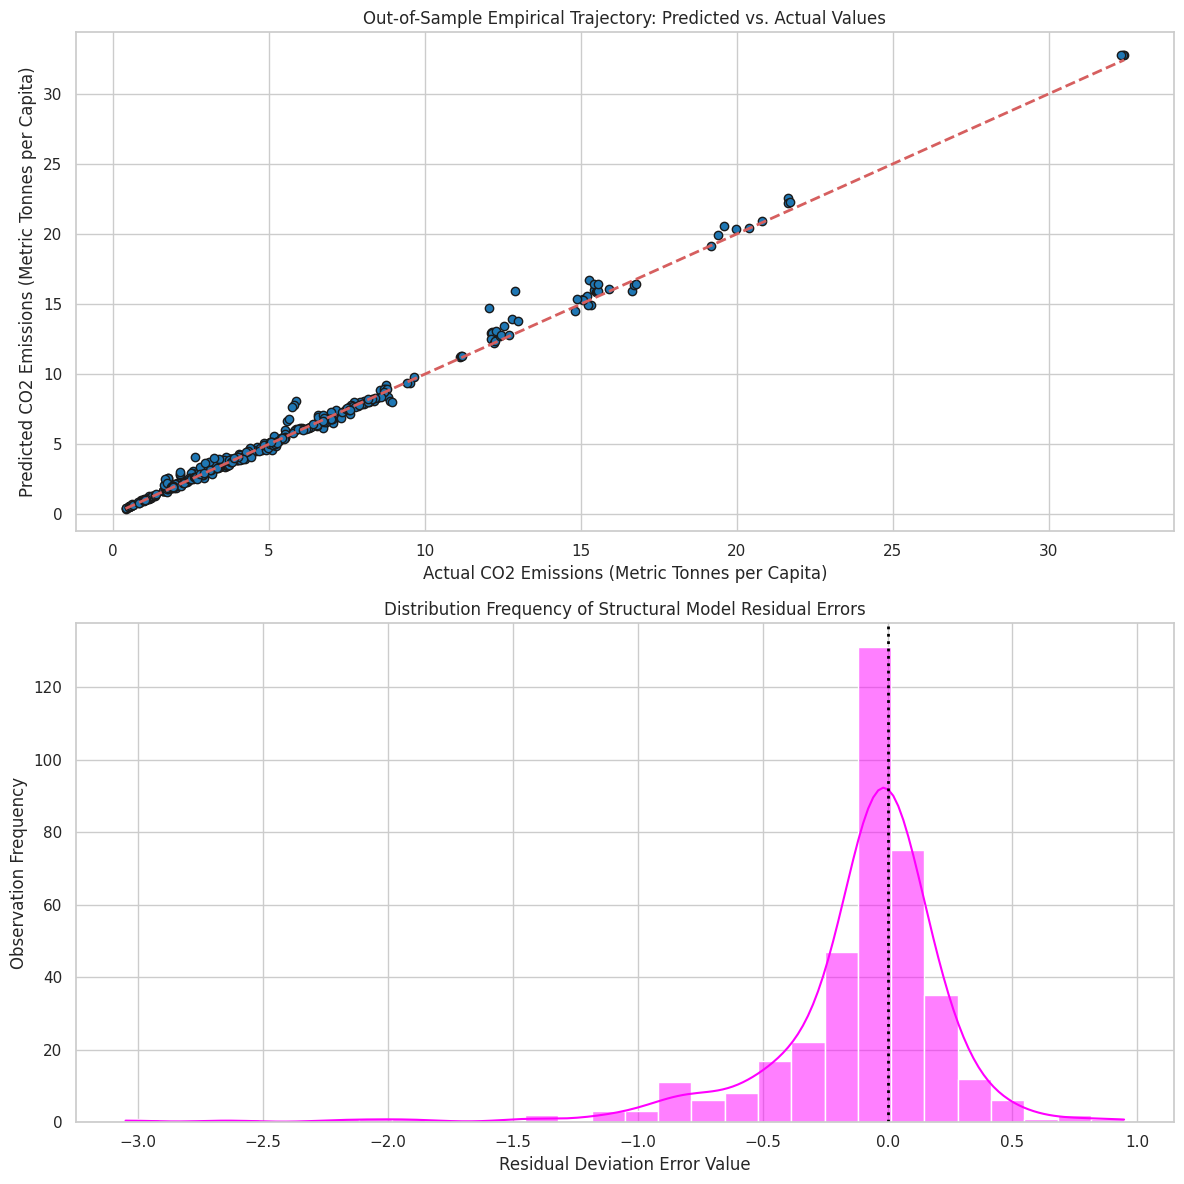

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].scatter(y_test, rf_test_preds, alpha=1, color='#1f77b4', edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Out-of-Sample Empirical Trajectory: Predicted vs. Actual Values')
axes[0].set_xlabel('Actual CO2 Emissions (Metric Tonnes per Capita)')
axes[0].set_ylabel('Predicted CO2 Emissions (Metric Tonnes per Capita)')

residuals = y_test - rf_test_preds
sns.histplot(residuals, kde=True, ax=axes[1], color='magenta', bins=30)
axes[1].axvline(0, color='black', linestyle=':', linewidth=2)
axes[1].set_title('Distribution Frequency of Structural Model Residual Errors')
axes[1].set_xlabel('Residual Deviation Error Value')
axes[1].set_ylabel('Observation Frequency')

plt.tight_layout()
plt.savefig('chart_11_residuals.png')
plt.show()

## 7.1 Analytical Insights from Feature Attribution and Diagnostics

Evaluating the feature importance scores and model residuals provides key insights into global carbon pathways:
- The model attribution framework shows that `co2_emissions_lag_1` dominates the split variance calculation at 75.05%, followed by `co2_emissions_lag_2` at 22.39%. Together, these temporal variables explain 97.44% of the predictive weight, indicating high path-dependency and structural inertia in national carbon trajectories. This confirms that a country's short-term carbon emissions are heavily influenced by its existing industrial asset base and energy infrastructure.
- Beyond temporal persistence, secondary structural drivers include the `natural_capital_dependency_index` (0.59%), `ecological_pressure_ratio` (0.36%), and `total_population` (0.31%). These reflect the underlying influence of resource extraction reliance, consumer footprint demands, and demographic scale on a country's emissions profile.
- The residual diagnostics validate the overall modeling approach. The actual versus predicted scatter alignment tracks the 45-degree reference line closely across different scales of carbon intensity. Furthermore, the residual error distribution is tightly centered at zero with a symmetric bell shape, confirming that the ensemble models effectively capture structural relationships without introducing systematic prediction bias.